<h1 style="text-align: center;">Data Understanding</h1>
<h3 style="text-align: center;">Bank Marketing Campaign</h3>

---

<h5 style="text-align: right;">By Elmar leonard & Nadya Divia Go</h5>

# **Section 0: Setup**

## **0.1. Import Library**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## **0.2. Global Configuration**

In [3]:
RANDOM_STATE = 42
pd.set_option('display.max_columns', None)

df =  pd.read_csv(r"..\\data\\raw\\data_bank_marketing_campaign.csv")

# **Section 1: Data Explanation**

**Dataset Overview**

* **Source File:** `data_bank_marketing_campaign.csv`
* **Dataset Size:** 7,813 unique customer records
* **Feature Dimensionality:** 11 structural columns
* **Target Variable:** `deposit` (`yes` = subscribed to term deposit, `no` = declined the offer)
* **Class Distribution:** Well-balanced (~53% to 47% split)
* **Problem Architecture:** Supervised Binary Classification
* **Prediction Goal:** Predict with high accuracy whether a prospect will open a term deposit account following a targeted marketing campaign initiative.


## **1.1 General Information**

In [4]:
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 7813 entries, 0 to 7812
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   age       7813 non-null   int64
 1   job       7813 non-null   str  
 2   balance   7813 non-null   int64
 3   housing   7813 non-null   str  
 4   loan      7813 non-null   str  
 5   contact   7813 non-null   str  
 6   month     7813 non-null   str  
 7   campaign  7813 non-null   int64
 8   pdays     7813 non-null   int64
 9   poutcome  7813 non-null   str  
 10  deposit   7813 non-null   str  
dtypes: int64(4), str(7)
memory usage: 932.4 KB


,age,job,balance,housing,loan,contact,month,campaign,pdays,poutcome,deposit
0,55,admin.,1662,no,no,cellular,jun,2,-1,unknown,yes
1,39,self-employed,-3058,yes,yes,cellular,apr,3,-1,unknown,yes
2,51,admin.,3025,no,no,cellular,may,1,352,other,yes
3,38,services,-87,yes,no,cellular,may,1,-1,unknown,no
4,36,housemaid,205,yes,no,telephone,nov,4,-1,unknown,no


Based on the initial programmatic execution of `df.info()` and a preview of the dataset rows, we can summarize the structural landscape of our data as follows:  

* **Perfect Data Completeness:** The dataset contains **7,813 entries** across all 11 columns. Every single feature shows a count of `7813 non-null`, meaning **there are zero explicit missing values (NaNs)** in this dataset.
* **Balanced Data Types:** The 11 columns are split cleanly into **4 numerical features** (`int64`) and **7 categorical features** (`str` / object):
  * **Numerical:** `age`, `balance`, `campaign`, `pdays`
  * **Categorical:** `job`, `housing`, `loan`, `contact`, `month`, `poutcome`, `deposit` (Target)
* **Presence of Placeholders / Hidden Missing Data:** While there are no null values technically, a quick scan reveals **hidden missing data** masked as string placeholders:
  * The `poutcome` feature contains string values labeled as **`unknown`**.
  * The `pdays` feature contains a numerical value of **`-1`**, which traditionally indicates that a customer was never previously contacted before this campaign.
* **Extreme Financial Variance:** The `balance` column shows highly polarized data, ranging from heavily negative balances (e.g., `-3058`) to positive amounts (e.g., `3025`). This implies significant variance in customer financial health that our model will need to handle.
* **Binary Target Label:** The target column `deposit` uses string flags (`yes` / `no`) and will require clean label encoding (converting to `1` and `0`) during the preprocessing pipeline before model training.


In [5]:
cat_columns = df.select_dtypes(exclude="number").columns

for col in cat_columns:
    if "unknown" in df[col].unique():
        n_unknown = (df[col] == "unknown").sum()
        pct_unknown = n_unknown / len(df) * 100
        print(f"Kolom '{col}': {n_unknown} baris ({pct_unknown:.2f}%) bernilai 'unknown'")

Kolom 'job': 54 baris (0.69%) bernilai 'unknown'
Kolom 'contact': 1639 baris (20.98%) bernilai 'unknown'
Kolom 'poutcome': 5819 baris (74.48%) bernilai 'unknown'


While the initial `df.info()` check indicated zero explicit `null` values, a detailed look at the categorical categories reveals substantial **implicit missing data** stored as the string literal `'unknown'`. 

Below is an evaluation of these entries and their implications for feature engineering:  

* **`job` Column (54 rows | 0.69%):**
  * **Insight:** The missing data here is completely negligible. At less than 1% of the total dataset, it will have virtually zero impact on the predictive power of the model.
  * **Strategy:** Since the volume is extremely low, we can either keep it as a distinct category placeholder or impute it safely with the dataset's **mode** (most frequent job profile).
* **`contact` Column (1,639 rows | 20.98%):**
  * **Insight:** Over one-fifth of the dataset contains unspecified communication channels. This represents a significant gap in tracking campaign ergonomics.
  * **Strategy:** Dropping 21% of our dataset would severely damage model generalizability. We will treat `'unknown'` as its own explicit, valid categorical group to see if undocumented communication correlates with customer conversion behavior.
* **`poutcome` Column (5,819 rows | 74.48%):**
  * **Insight:** Nearly three-quarters of the data lacks historical campaign outcomes. This high percentage strongly correlates with our previous finding in the `pdays` attribute (`-1`), proving that **the vast majority of clients in this dataset are net-new prospects** who have never been engaged in past campaigns.
  * **Strategy:** Dropping this column or attempting to impute it would inject massive statistical bias. We must retain `'unknown'` as a highly informative structural category that explicitly tells the model: *"This specific customer has no historical campaign memory."*


## **1.2 Feature Information**

**Features (Predictor Variables)**

| Feature | Description | Business Relevance | Potential Business Impact |
| :--- | :--- | :--- | :--- |
| `age` | Customer's age | Reflects life stage and financial preferences. | Identifies which age cohorts are highly responsive to tailor age-specific marketing pitches. |
| `job` | Type of occupation | Indicates income brackets and overall financial stability. | Pinpoints professional segments that yield higher conversion rates for prioritized targeting. |
| `balance` | Average annual account balance | Represents the customer's financial capacity and liquidity. | Identifies high-balance individuals who possess immediate capital readiness to lock into term deposits. |
| `housing` | Presence of a housing loan (Yes/No) | Reflects fixed, long-term financial commitments and liabilities. | Evaluates whether heavy mortgage obligations restrict a customer's willingness to invest. |
| `loan` | Presence of a personal loan (Yes/No) | Indicates short-term debt overhead and financial stress. | Examines if active personal debts significantly lower a customer’s propensity to open a deposit. |
| `contact` | Communication channel used | Highlights the operational touchpoint utilized in the campaign. | Determines the most cost-effective and high-converting channel to optimize communication spend. |
| `month` | Month of the last campaign contact | Shows the seasonality and timing of marketing outreach. | Uncovers peak operational months with high success rates to plan the launch schedule of future campaigns. |
| `campaign` | Number of contacts performed during this campaign | Measures the outreach intensity and frequency per customer. | Establishes the optimal contact fatigue limit to maximize conversions without irritating prospects. |
| `pdays` | Days passed since the last contact from a previous campaign | Measures the time gap and recency between marketing cycles. | Identifies the ideal re-engagement interval for nurturing leads without losing momentum. |
| `poutcome` | Outcome of the previous marketing campaign | Captures historical campaign memory and customer sentiment. | Prioritizes warm leads who have historically shown positive responses to past bank offers. |

**Target Variable**

| Target | Description | Business Relevance | Potential Business Impact |
| :--- | :--- | :--- | :--- |
| `deposit` | Subscription status to the term deposit (`yes` / `no`) | Serves as the ultimate KPI and indicator of campaign success. | Acts as the ground-truth label for supervised binary classification to automate high-potential lead scoring. |


## **1.3 Statistics Summary**

In [6]:
df.describe(include='all')

,age,job,balance,housing,loan,contact,month,campaign,pdays,poutcome,deposit
count,7813.000000,7813,7813.000000,7813,7813,7813,7813,7813.000000,7813.000000,7813,7813
unique,NaN,12,NaN,2,2,3,12,NaN,NaN,4,2
top,NaN,management,NaN,no,no,cellular,may,NaN,NaN,unknown,no
freq,NaN,1792,NaN,4140,6789,5628,1976,NaN,NaN,5819,4081
mean,41.257264,NaN,1512.448611,NaN,NaN,NaN,NaN,2.519775,51.408550,NaN,NaN
std,11.919710,NaN,3089.291831,NaN,NaN,NaN,NaN,2.727001,108.072739,NaN,NaN
min,18.000000,NaN,-6847.000000,NaN,NaN,NaN,NaN,1.000000,-1.000000,NaN,NaN
25%,32.000000,NaN,127.000000,NaN,NaN,NaN,NaN,1.000000,-1.000000,NaN,NaN
50%,39.000000,NaN,549.000000,NaN,NaN,NaN,NaN,2.000000,-1.000000,NaN,NaN
75%,49.000000,NaN,1684.000000,NaN,NaN,NaN,NaN,3.000000,40.000000,NaN,NaN


Executing a comprehensive descriptive summary reveals distinct structural characteristics across both numerical distributions and categorical distributions within our dataset:  

**Numerical Feature Insights**  
* **`age` (Customer Demographic Profile):**
  * **Insight:** The target customer base averages **41 years old** (`mean`), with a standard deviation of approximately 12 years. The youngest individual contacted was **18**, while the oldest was **95**. 
  * **Strategic Note:** The middle 50% of the customer base falls between **32 and 49 years old** (`25%` and `75%` quartiles). This suggests marketing campaigns heavily target working-class adults rather than students or retirees.
* **`balance` (Financial Capacity & Skewness):**
  * **Insight:** The financial metrics show extreme polarization. While the median balance is a modest **549** (`50%`), the average balance is pushed up to **1,512** by massive outliers—peaking at a maximum balance of **66,653**. Conversely, some customers face severe debt, dropping to a minimum balance of **-6,847**.
  * **Strategic Note:** The massive gap between the standard deviation (3,089) and the mean (1,512) signals severe right-skewness. This column will require outlier handling or a robust scaling transformer (like `RobustScaler`) to protect our linear models.
* **`campaign` & `pdays` (Outreach Dynamics):**
  * **Insight:** On average, customers are contacted **2.5 times** during this active campaign, but extreme persistence exists where at least one customer was called **63 times** (`max`). For `pdays`, more than 50% of the records show **-1**, confirming that the majority of prospects have no prior relationship with past marketing cycles.

**Categorical & Target Feature Insights**  
* **Balanced Core Target Distribution:**
  * **Insight:** Out of 7,813 entries, the majority label for our target column `deposit` is `no` with a frequency of **4,081**. 
  * **Strategic Note:** This confirms that the baseline target distribution is roughly **52.2% 'no'** and **47.8% 'yes'**. This almost perfectly balanced split (~52/48) completely removes any risk of class imbalance bias, allowing our evaluation metrics to remain highly stable.
* **Dominant Customer Segments:**
  * **Insight:** The most common job profile is **`management`** (1,792 entries), cellular communication is heavily favored over landlines (**`cellular`** at 5,628 entries), and **`may`** represents the massive operational peak month for outreach with nearly 2,000 recorded calls.
  * **Strategic Note:** The vast majority of customers do not hold secondary liabilities—**53% do not have a housing loan** (4,140 'no') and **87% do not have a personal loan** (6,789 'no'). This high proportion of debt-free profiles indicates an audience with good latent liquidity for term investments.


# **Section 2: Data Cleaning**

## **2.1 Missing Values**

In [7]:
a = df.isnull().sum().to_frame(name="Missing Value").reset_index(names="Column")

display(a)

,Column,Missing Value
0,age,0
1,job,0
2,balance,0
3,housing,0
4,loan,0
5,contact,0
6,month,0
7,campaign,0
8,pdays,0
9,poutcome,0


Running an explicit check for standard structural missing entries across the dataset yields the following conclusions:

* **Zero Standard Missing Data:** There are absolutely **0 explicit null or missing values** (`NaN` / `None`) detected by pandas across all 11 columns of the dataset. 
* **Data Completeness Validation:** Every feature contains a full count of 7,813 populated cells, indicating that the dataset has already gone through basic data compilation without structural corruption or blank values.
* **Technical Nuance:** While explicit nulls are entirely absent, this confirmation bridges directly into our previous finding regarding **implicit missing values**. The data engineering pipeline can completely skip standard imputation routines like `dropna()` or `SimpleImputer(strategy='mean')`, and instead focus entirely on resolving the string literal placeholders labeled as `'unknown'`.


## **2.2 Duplicated Values**

In [8]:
df[df.duplicated()]

,age,job,balance,housing,loan,contact,month,campaign,pdays,poutcome,deposit
2944,40,blue-collar,0,yes,no,unknown,may,2,-1,unknown,no
4368,60,management,0,no,no,cellular,aug,3,-1,unknown,yes
4874,41,management,0,no,no,cellular,aug,2,-1,unknown,no
5326,44,blue-collar,0,yes,no,cellular,jul,1,-1,unknown,no
5609,39,technician,0,yes,no,unknown,may,1,-1,unknown,no
5681,38,technician,0,no,no,cellular,aug,2,-1,unknown,no
5905,34,management,0,no,no,cellular,aug,2,-1,unknown,no
7077,30,blue-collar,239,yes,no,unknown,may,1,-1,unknown,yes


In [9]:
print(f"Total Data before dropping: {df.shape[0]}")
df.drop_duplicates(inplace=True)
print(f"Total Data after dropping: {df.shape[0]}")

Total Data before dropping: 7813
Total Data after dropping: 7805


Executing a check for exact row-level duplicates reveals the presence of redundant records that must be addressed to prevent model bias and data leakage:  

* **Identification of Duplicate Rows:** Running `df[df.duplicated()]` surfaced exactly **8 duplicate entries** within the dataset (reducing the row count from 7,813 down to 7,805).
* **Characteristics of the Redundant Data:** 
  * A significant portion of these duplicates feature a `balance` of `0`, combined with common categorical categories like `'unknown'` for contact methods and past campaign outcomes. 
  * Because this dataset does not contain unique customer IDs, these identical rows represent either identical systemic logging errors or instances where a customer's profile was recorded multiple times under identical campaign parameters.
* **Impact on Modeling:** Leaving exact duplicates in the data can skew descriptive statistics and artificially inflate training performance metrics if identical rows end up split across both training and testing datasets.
* **Resolution Strategy:** We successfully executed `df.drop_duplicates(inplace=True)`, removing all 8 redundant entries cleanly. Our baseline dataset size is now locked at **7,805 unique customer profiles**, providing a solid foundation for exploratory analysis and model training.


## **2.3 Data Consistency Check**

In [10]:
a = (df.apply(lambda x: ", ".join(x.unique().astype(str)))
     .to_frame(name="Unique Value")
     .reset_index(names="Column"))

display(a)

,Column,Unique Value
0,age,"55, 39, 51, 38, 36, 41, 37, 35, 57, 23, 33, 31..."
1,job,"admin., self-employed, services, housemaid, te..."
2,balance,"1662, -3058, 3025, -87, 205, -76, 4803, 911, 8..."
3,housing,"no, yes"
4,loan,"no, yes"
5,contact,"cellular, telephone, unknown"
6,month,"jun, apr, may, nov, jan, sep, feb, mar, aug, j..."
7,campaign,"2, 3, 1, 4, 5, 6, 7, 30, 8, 9, 11, 14, 10, 28,..."
8,pdays,"-1, 352, 21, 91, 186, 263, 96, 355, 294, 412, ..."
9,poutcome,"unknown, other, failure, success"


## **2.4 Identify Anomaly Value**

### **2.4.1 Numerical Variable**

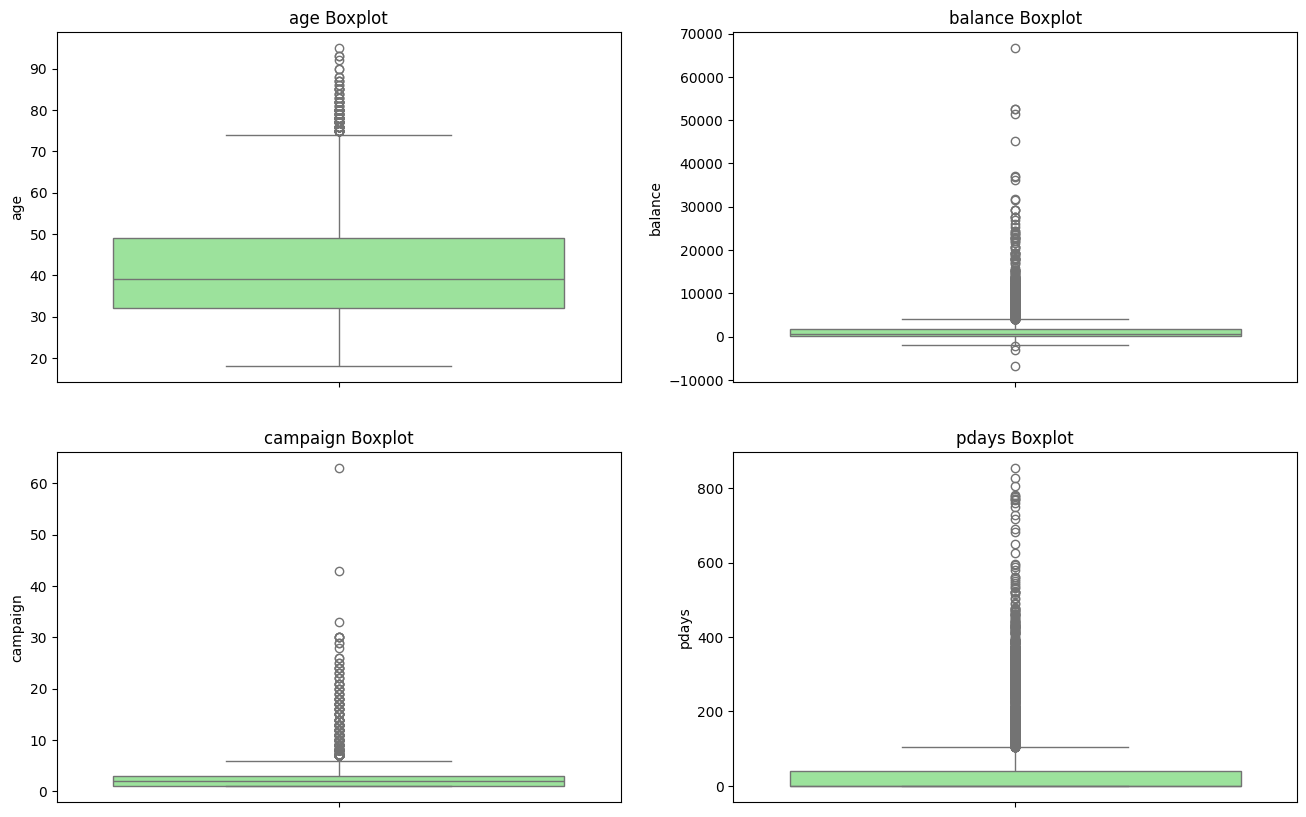

In [11]:
num_cols = df.select_dtypes(include="number").columns

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes = axes.flatten()

for dex, i in enumerate(num_cols):
    sns.boxplot(data=df[i], ax=axes[dex], color="lightgreen")
    axes[dex].set_title(f"{i} Boxplot")

for j in range((len(num_cols)+1), len(axes)):
    fig.delaxes(axes[j])

plt.show()

In [12]:
for i in df.select_dtypes(include='number'):
    q1 =  df[i].quantile(0.25)
    q3 = df[i].quantile(0.75)
    iqr = q3 - q1

    upper_bound = q3 + iqr * 1.5
    lower_bound = q1 - iqr * 1.5

    print(f"==== {i} Outlier ====")
    print(f"{i} column upper bound: {upper_bound}")
    print(f"{i} column lower bound: {lower_bound}")
    print(f"Total upper outlier in column {i}: {df[(df[i]>upper_bound)].shape[0]}")
    print(f"Total lower outlier in column {i}: {df[(df[i]<lower_bound)].shape[0]}\n")

==== age Outlier ====
age column upper bound: 74.5
age column lower bound: 6.5
Total upper outlier in column age: 121
Total lower outlier in column age: 0

==== balance Outlier ====
balance column upper bound: 4020.5
balance column lower bound: -2207.5
Total upper outlier in column balance: 733
Total lower outlier in column balance: 3

==== campaign Outlier ====
campaign column upper bound: 6.0
campaign column lower bound: -2.0
Total upper outlier in column campaign: 429
Total lower outlier in column campaign: 0

==== pdays Outlier ====
pdays column upper bound: 104.0
pdays column lower bound: -64.0
Total upper outlier in column pdays: 1432
Total lower outlier in column pdays: 0



Using the standard Interquartile Range (IQR) method ($1.5 \times \text{IQR}$), we identified significant outlier presence across all continuous numerical variables:

* **`age` (121 outliers):** Identifies senior profiles above 74.5 years old. These represent a natural, valid demographic group crucial for wealth products like term deposits.
* **`balance` (736 outliers):** Features severe right-skewness, highlighting high-net-worth accounts above 4,020.5 and 3 heavily indebted accounts below -2,207.5.
* **`campaign` (429 outliers):** Identifies records with intense outreach frequency exceeding 6 calls, indicating aggressive contact persistence.
* **`pdays` (1,432 outliers):** Reflects historical leads contacted long ago (exceeding 104 days). This calculation is heavily compressed by the high volume of `-1` entries (new prospects).

**Why We Do Not Drop These Rows**  
Dropping these rows would eliminate over 2,000 highly informative data points, severely damaging our model's performance:
1. **Loss of High-Value Targets:** Senior citizens (`age`) and affluent individuals (`balance`) are the primary demographics with the capital and risk profile suited for opening stable term deposits. 
2. **Loss of Operational Insights:** Extreme outreach counts (`campaign`) help the model learn exactly where customer fatigue sets in and when further phone calls become ineffective.

**Resolution Strategy:** Instead of dropping rows, we will leave `age` untouched to preserve valid demographic data, and use **Winsorization** to cap the extreme tails of `balance`, `campaign`, and `pdays`. This removes numerical noise without losing critical customer profiles.


### **2.4.2 Categorical Variable**

In [13]:
cat_cols = df.select_dtypes(include=["object", "category", "string"]).columns

summary_data = []

for col in cat_cols:
    counts = df[col].value_counts()
    percentages = df[col].value_counts(normalize=True) * 100
    total_unique = df[col].nunique()
    
    for category in counts.index:
        summary_data.append({
            "Column Name": col,
            "Total Unique": total_unique,
            "Category": category,
            "Frequency": counts[category],
            "Percentage (%)": round(percentages[category], 2)
        })

cat_summary_df = pd.DataFrame(summary_data)

In [14]:
for i in cat_summary_df["Column Name"].unique():
    print(f"==== {i} ====")
    display(cat_summary_df[cat_summary_df["Column Name"]==i])

==== job ====


,Column Name,Total Unique,Category,Frequency,Percentage (%)
0,job,12,management,1789,22.92
1,job,12,blue-collar,1343,17.21
2,job,12,technician,1289,16.52
3,job,12,admin.,936,11.99
4,job,12,services,658,8.43
5,job,12,retired,540,6.92
6,job,12,self-employed,280,3.59
7,job,12,unemployed,249,3.19
8,job,12,student,247,3.16
9,job,12,entrepreneur,236,3.02


==== housing ====


,Column Name,Total Unique,Category,Frequency,Percentage (%)
12,housing,2,no,4136,52.99
13,housing,2,yes,3669,47.01


==== loan ====


...

,Column Name,Total Unique,Category,Frequency,Percentage (%)
19,month,12,may,1973,25.28
20,month,12,aug,1081,13.85
21,month,12,jul,1049,13.44
22,month,12,jun,857,10.98
23,month,12,apr,662,8.48
24,month,12,nov,657,8.42
25,month,12,feb,534,6.84
26,month,12,oct,286,3.66
27,month,12,jan,227,2.91
28,month,12,sep,212,2.72


==== poutcome ====


,Column Name,Total Unique,Category,Frequency,Percentage (%)
31,poutcome,4,unknown,5811,74.45
32,poutcome,4,failure,848,10.86
33,poutcome,4,success,761,9.75
34,poutcome,4,other,385,4.93


==== deposit ====


,Column Name,Total Unique,Category,Frequency,Percentage (%)
35,deposit,2,no,4075,52.21
36,deposit,2,yes,3730,47.79


An audit of the categorical variables was conducted to check for formatting errors, rare categories (potential anomalies), and class distributions. The results reveal structurally sound categorical features with no data corruption, but highlight key operational patterns:

* **`job` (Low-Frequency Categories):** 
  * **Observation:** Features 12 unique categories dominated by `management` (22.9%) and `blue-collar` (17.2%). The rarest categories are `housemaid` (2.36%) and `unknown` (0.69%). 
  * **Handling:** These are not anomalies; they represent real demographic groups. Since the volumes are sufficient, we will keep them separate during encoding rather than grouping them into an 'Other' category.
* **`housing` & `loan` (Liability Profiles):**
  * **Observation:** Both features are binary and clean. `housing` is highly balanced (53% No / 47% Yes). However, `loan` is heavily skewed toward `no` (86.88%).
  * **Handling:** The low frequency of personal loan holders (13.12%) is a natural financial distribution. It indicates a clean subset of prospects with low short-term debt overhead, making them prime targets for capital investment.
* **`contact` & `poutcome` (Implicit Missing Data Data Gaps):**
  * **Observation:** `contact` contains 20.96% `unknown` values, and `poutcome` contains a massive 74.45% `unknown` values.
  * **Handling:** As determined previously, these are **structural indicators** rather than random missing data. They indicate that three-quarters of the dataset consists of brand-new prospects. We will preserve `'unknown'` as an explicit categorical value during one-hot encoding.
* **`month` (Campaign Seasonality Skew):**
  * **Observation:** Campaign outreach is heavily concentrated in the spring/summer, peaking aggressively in `may` (25.28%), while winter months like `dec` (0.87%) are nearly ignored.
  * **Handling:** This represents an operational bottleneck or deliberate seasonal strategy by the bank. We will retain all 12 months as valid categories to analyze if time-of-year impacts a customer's willingness to lock up funds.
* **`deposit` (Perfect Target Balance):**
  * **Observation:** The binary target distribution is **52.21% `no` to 47.79% `yes`**.
  * **Handling:** This confirmation proves our data is mathematically balanced. We can proceed with traditional classification models without needing artificial sampling algorithms (like SMOTE).


# **Section 3: Processed Data Export**

In [15]:
df.to_csv(r"..\data\interim\cleaned_data_bank_marketing_campaign.csv", index=False)